In [1]:
from langgraph.graph import StateGraph, START, END
from langchain_core.tools import tool
from langchain_community.document_loaders import PyPDFLoader
from langchain_community.vectorstores import FAISS
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_groq import ChatGroq
from typing import TypedDict,Annotated
from langgraph.graph import add_messages
from langgraph.checkpoint.memory import MemorySaver
from langgraph.prebuilt import ToolNode,tools_condition
from langchain.messages import HumanMessage


from dotenv import load_dotenv
load_dotenv(override=True)

C:\Users\pumas\AppData\Local\Temp\ipykernel_21232\920727356.py:3: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import PyPDFLoader
c:\Users\pumas\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
python-dotenv could not parse statement starting at line 7


True

In [2]:
model = ChatGroq(model="openai/gpt-oss-20b")
embeddings = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2"
)

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 3181.95it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [3]:
loader = PyPDFLoader(file_path= r"C:\Users\pumas\Desktop\AgenticAI\Langraph\genai-interview-questions.pdf")
docs = loader.load()
docs

[Document(metadata={'producer': 'Microsoft® Word 2019', 'creator': 'Microsoft® Word 2019', 'creationdate': '2025-02-15T18:21:57+05:30', 'author': 'Rajesh Srivastava', 'moddate': '2026-03-09T12:01:52+05:30', 'source': 'C:\\Users\\pumas\\Desktop\\AgenticAI\\Langraph\\genai-interview-questions.pdf', 'total_pages': 59, 'page': 0, 'page_label': '1'}, page_content='1 | P a g e \n \n \n \n \n \nGenerative AI \n \nInterview Q & A \n \n \n \n \n \n \n \n \n \nI'),
 Document(metadata={'producer': 'Microsoft® Word 2019', 'creator': 'Microsoft® Word 2019', 'creationdate': '2025-02-15T18:21:57+05:30', 'author': 'Rajesh Srivastava', 'moddate': '2026-03-09T12:01:52+05:30', 'source': 'C:\\Users\\pumas\\Desktop\\AgenticAI\\Langraph\\genai-interview-questions.pdf', 'total_pages': 59, 'page': 1, 'page_label': '2'}, page_content='2 | P a g e \n \nTable of Contents \n \nGeneric Questions ........................................................................................................................

In [4]:
splitter = RecursiveCharacterTextSplitter(chunk_size = 1000,chunk_overlap = 200)
chunks = splitter.split_documents(docs)

In [5]:
vector_store = FAISS.from_documents(chunks,embedding=embeddings)

In [6]:
retriever = vector_store.as_retriever(search_type = "similarity",kwargs={'k':5})

In [7]:
retriever.invoke("What is BERT, and how is it used in Generative AI? ")

[Document(id='e1689c04-cb6e-4abd-b687-6068894a8397', metadata={'producer': 'Microsoft® Word 2019', 'creator': 'Microsoft® Word 2019', 'creationdate': '2025-02-15T18:21:57+05:30', 'author': 'Rajesh Srivastava', 'moddate': '2026-03-09T12:01:52+05:30', 'source': 'C:\\Users\\pumas\\Desktop\\AgenticAI\\Langraph\\genai-interview-questions.pdf', 'total_pages': 59, 'page': 6, 'page_label': '7'}, page_content='7 | P a g e \n \nprocess entire sequences in parallel, which makes them more efficient and better at \ncapturing long-range dependencies. \nQ: What is BERT, and how is it used in Generative AI? \nA: BERT (Bidirectional Encoder Representations from Transformers) is a pre-trained \nlanguage model designed for understanding context in text by considering both the left and \nright surroundings. While BERT itself is not generative, its architecture can be adapted for \ntext generation tasks in models like GPT (Generative Pre-trained Transformer). It’s Encoder \nonly Model. \nQ: How does GPT di

In [8]:
class State(TypedDict):
    messages: Annotated[list, add_messages]

In [9]:
graph = StateGraph(State)

In [10]:
@tool
def rag_tool(query:str):
    """It is a RAG tool used to retrieve relevant information from the external source.
    It takes a query input and returns the relevant document from the database based on the similarity between the too.
    Used when a user uploads a pdf, and asks question based on that pdf
    """
    result = retriever.invoke(query)

    content = [i.page_content for i in result]
    metadata = [i.metadata for i in result]

    return {
        'query':query,
        'content':content,
        'metadata':metadata
    }

In [11]:
tools = [rag_tool]
llm_with_tools = model.bind_tools(tools)

def chatnode(state):
    messages = state["messages"]

    response = llm_with_tools.invoke(messages)

    return {"messages": [response]}

tool_node = ToolNode(tools)

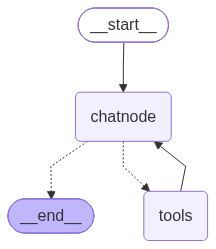

In [12]:
chekckpoint = MemorySaver()

graph.add_node("chatnode",chatnode)
graph.add_node("tools",tool_node)

graph.add_edge(START,"chatnode")
graph.add_conditional_edges("chatnode",tools_condition)
graph.add_edge("tools","chatnode")

workflow = graph.compile(checkpointer=chekckpoint)
workflow

In [13]:
config = {
    "configurable": {
        "thread_id": "1"
    }
}

query = "Use the tool and tell me what is Generative AI. Give the page number."

result = workflow.invoke(
    {"messages": [HumanMessage(content=query)]},
    config=config
)

print(result["messages"][-1].content)

**Generative AI**  
Generative AI refers to a class of artificial‑intelligence models that can create new data or content—such as text, images, audio, or other media—based on the patterns they learned from the data they were trained on. These models generate fresh, novel samples that resemble the training data, enabling applications like chatbots, art creation, music composition, and more.

*Page reference:* **Page 3** of the document.
